In [1]:
import pandas as pd

In [2]:
embedding_dims = 32
random_state = 2020
n_transactions_context = 20
n_examples = 3000
input_dim = 1537

#### Objective:

Evaluate the Fraud Detection Model (out of data).

#### Depends on:

In [ ]:
df_fname = "./data/05-dataframe-with-vectors.parquet"
triplet_loss_model_fname = "./data/triplet_loss_model_4_agencies.pth"
fraud_detection_model_fname = "./data/fraud_detection_model_4_agencies.pth"

In [3]:
df = pd.read_parquet(df_fname)  # this takes 4GB

In [4]:
# DEPARTMENT OF REHABILITATION SERVICES | 80500
# DEPARTMENT OF TOURISM AND RECREATION | 56600
# UNIV. OF OKLA. HEALTH SCIENCES CENTER | 77000
# MENTAL HEALTH AND SUBSTANCE ABUSE SERV. | 45200
df = df[df.agency_number.isin([80500, 56600, 77000, 45200])]

In [5]:
df = df.sample(n=n_examples, random_state=random_state)

In [6]:
drop_cols = [
    "cohort",
    "agency_name",
    "holder_last_name",
    "holder_first_initial",
    "amount",
    "vendor",
    "mcc",
    "posted_date",
]  # keep 'transaction_date', 'agency_number', 'parsed_amount' and repr of mcc and vendor
label_col = "agency_number"

In [7]:
df.drop(drop_cols, axis=1, inplace=True)

In [8]:
input_dim = (
    len(df.columns) - 2
)  # 'transaction_date', 'agency_number' will not go into the model

In [9]:
import torch
import numpy as np
import random
from sklearn import model_selection
import torch.nn as nn
import copy
from tqdm.notebook import tqdm

In [10]:
torch.manual_seed(random_state)
np.random.seed(random_state)
random.seed(random_state)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.cuda.get_device_name()

In [11]:
class EmbeddingModel(nn.Module):
    def __init__(self, input_dim=1537, emb_dim=32):
        super(EmbeddingModel, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.PReLU(),
            nn.Linear(input_dim, 1024),
            nn.PReLU(),
            nn.Linear(1024, 1024),
            nn.PReLU(),
            nn.Linear(1024, 128),
            nn.PReLU(),
            nn.Linear(128, 64),
            nn.PReLU(),
            nn.Linear(64, 64),
            nn.PReLU(),
            nn.Linear(64, emb_dim),
        )

    def forward(self, x):
        x = self.fc(x)
        return x

In [12]:
class Classifier(nn.Module):
    def __init__(self, embedding_model, n_transactions_context, embedding_dims):
        super(Classifier, self).__init__()

        self.n_transactions_context = n_transactions_context
        self.embedding_dims = embedding_dims

        emb_models = []

        for i in range(n_transactions_context + 1):
            emb_models.append(copy.deepcopy(embedding_model))

        self.emb_models = nn.ModuleList(emb_models)

        self.fc = nn.Sequential(
            nn.Linear((n_transactions_context + 1) * embedding_dims, 512),
            nn.PReLU(),
            nn.Linear(512, 256),
            nn.PReLU(),
            nn.Linear(256, 128),
            nn.PReLU(),
            nn.Linear(128, 32),
            nn.PReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # print(x.shape)

        embs = [model(x[:, i]) for i, model in enumerate(self.emb_models)]

        # print("len(embs)", len(embs))

        # print("embs[0].shape", embs[0].shape)

        cat = torch.cat(embs, dim=1)

        # print("cat.shape", cat.shape)

        flat = cat.flatten(start_dim=1)

        # print("flat.shape", flat.shape)

        x = self.fc(flat)

        return x

In [13]:
emb_model = EmbeddingModel(input_dim, embedding_dims)

emb_model.eval()

EmbeddingModel(
  (fc): Sequential(
    (0): Linear(in_features=1537, out_features=1537, bias=True)
    (1): PReLU(num_parameters=1)
    (2): Linear(in_features=1537, out_features=1024, bias=True)
    (3): PReLU(num_parameters=1)
    (4): Linear(in_features=1024, out_features=1024, bias=True)
    (5): PReLU(num_parameters=1)
    (6): Linear(in_features=1024, out_features=128, bias=True)
    (7): PReLU(num_parameters=1)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): PReLU(num_parameters=1)
    (10): Linear(in_features=64, out_features=64, bias=True)
    (11): PReLU(num_parameters=1)
    (12): Linear(in_features=64, out_features=32, bias=True)
  )
)

In [14]:
emb_model.load_state_dict(torch.load(triplet_loss_model_fname))

<All keys matched successfully>

In [15]:
cl_model = Classifier(emb_model, n_transactions_context, embedding_dims)

In [16]:
cl_model.load_state_dict(torch.load(fraud_detection_model_fname))

<All keys matched successfully>

In [17]:
cl_model.eval()

Classifier(
  (emb_models): ModuleList(
    (0-20): 21 x EmbeddingModel(
      (fc): Sequential(
        (0): Linear(in_features=1537, out_features=1537, bias=True)
        (1): PReLU(num_parameters=1)
        (2): Linear(in_features=1537, out_features=1024, bias=True)
        (3): PReLU(num_parameters=1)
        (4): Linear(in_features=1024, out_features=1024, bias=True)
        (5): PReLU(num_parameters=1)
        (6): Linear(in_features=1024, out_features=128, bias=True)
        (7): PReLU(num_parameters=1)
        (8): Linear(in_features=128, out_features=64, bias=True)
        (9): PReLU(num_parameters=1)
        (10): Linear(in_features=64, out_features=64, bias=True)
        (11): PReLU(num_parameters=1)
        (12): Linear(in_features=64, out_features=32, bias=True)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=672, out_features=512, bias=True)
    (1): PReLU(num_parameters=1)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): PReLU(num_

In [18]:
df = df.set_index(["agency_number", "transaction_date"], drop=False).sort_index()

In [19]:
agencies = set(df.agency_number.unique())

In [20]:
X = np.zeros(
    (n_examples, n_transactions_context + 1, len(df.columns) - 2), dtype="float"
)
y = np.zeros((n_examples,), dtype="float")

In [21]:
for i in tqdm(range(0, n_examples, 2)):
    not_enough_transactions = True

    while not_enough_transactions:
        transaction = df.sample(1)

        try:
            earlier_transactions = df.loc[transaction.agency_number.values[0]][
                : transaction.transaction_date.values[0]
            ].sample(n_transactions_context)
            not_enough_transactions = False
        except ValueError:
            # print("sample new transaction")
            continue  # sample new transaction

    # positive example
    X[i, :n_transactions_context, :] = earlier_transactions.drop(
        ["transaction_date", "agency_number"], axis=1
    ).values
    X[i, n_transactions_context, :] = transaction.drop(
        ["transaction_date", "agency_number"], axis=1
    ).values
    y[i] = 1  # same agency

    negative_agency = np.random.choice(
        list(agencies.difference(transaction.agency_number.values))
    )

    # negative example
    negative_example = df.loc[negative_agency].sample(1)

    X[i + 1, :n_transactions_context, :] = earlier_transactions.drop(
        ["transaction_date", "agency_number"], axis=1
    ).values
    X[i + 1, n_transactions_context, :] = negative_example.drop(
        ["transaction_date", "agency_number"], axis=1
    ).values
    y[i + 1] = 0  # not the same agency

  0%|          | 0/1500 [00:00<?, ?it/s]

In [22]:
del df

In [23]:
with torch.no_grad():
    sample = X[:2].astype("float32")
    # print(sample.shape)
    sample_prediction = cl_model(torch.from_numpy(sample).cpu()).cpu().numpy()

sample_prediction

array([[0.9999994],
       [0.9947849]], dtype=float32)

In [24]:
len(X)

3000

In [25]:
cl_model.eval()
with torch.no_grad():
    pred = cl_model(torch.from_numpy(X.astype("float32")).cpu()).cpu().numpy()

In [26]:
from plothelpers import KS, PSI, ScoreDistribution
import matplotlib.pyplot as plt

In [27]:
pred.shape, y.shape

((3000, 1), (3000,))

In [28]:
len(y.shape)

1

In [29]:
pred.sum()

1551.2533

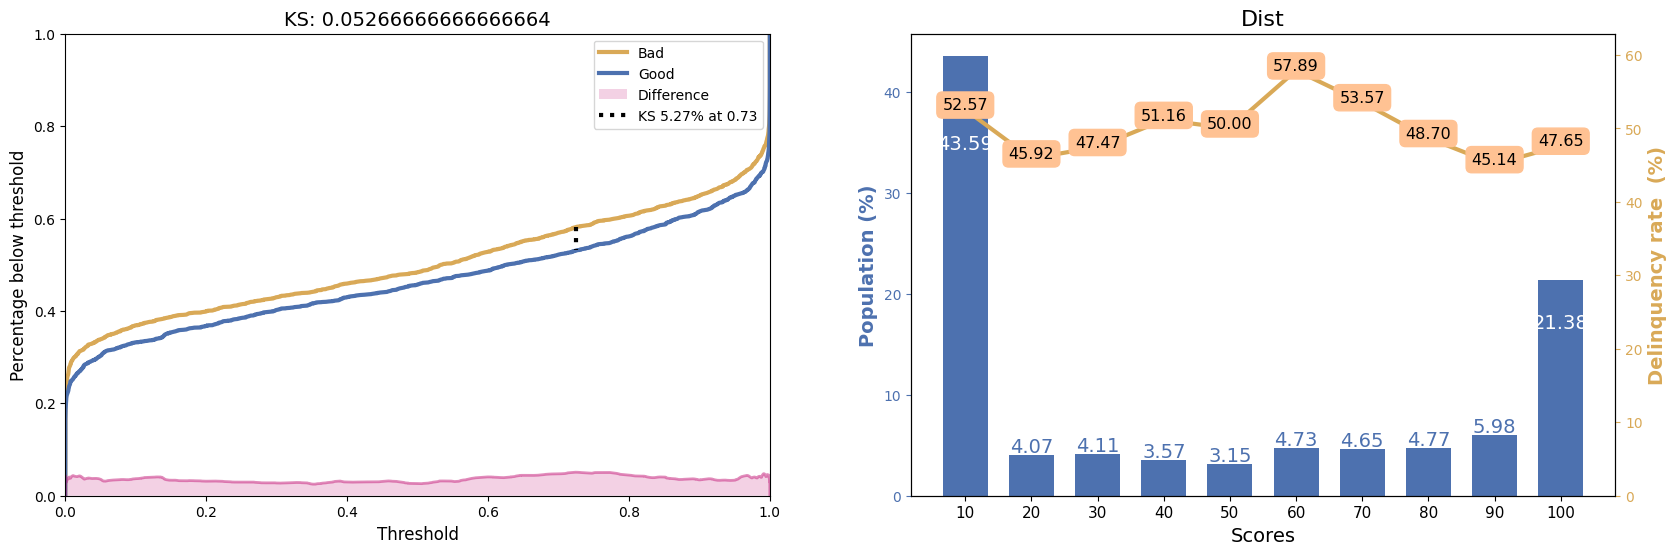

In [30]:
fig, axis = plt.subplots(1, 2, figsize=(20, 6), sharey=False, facecolor=(1, 1, 1))

ks = KS(pred.reshape(-1), y)

ks_value = ks.value

title = f"KS: {ks_value}"

ks.plot(title=title, ax=axis[0])

ScoreDistribution(pred.reshape(-1), y).plot("Dist", ax=axis[1])

In [32]:
max_diff_index = ks.diffs.argmax()

In [33]:
cut = ks.distribution[max_diff_index, 0]

In [34]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

In [35]:
y.shape

(3000,)

In [36]:
pred.shape

(3000, 1)

In [37]:
cm = confusion_matrix(y, pred.reshape(-1) > cut)

In [38]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

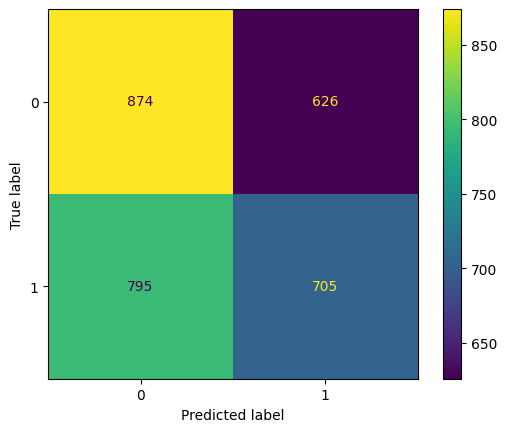

In [39]:
disp.plot()

In [40]:
precision, recall, fbeta, _ = precision_recall_fscore_support(
    y, pred.reshape(-1) > cut, average="binary"
)

In [41]:
precision, recall, fbeta

(0.5296769346356123, 0.47, 0.4980572235959025)